# Figure 4, bottom
## Projected crop exposure to thirstwaves by region

# Import libraries

In [1]:
import os
import geopandas as gp
import regionmask
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

# Create regional mask

In [2]:
regions_file = "/work10/archive/CMIP6/CMIP-SSPs/inputs/regionmasks/SSPs_30regions/SSPs_30regions_merged.shp"

# Load mask with 30 regions if it exists, otherwise create it
if os.path.exists(regions_file):
    regions = gp.read_file(regions_file)
else:
    regions = gp.read_file("/work10/archive/CMIP6/CMIP-SSPs/inputs/regionmasks/SSPs_30regions/SSPs_30regions.shp")
    regions = regions.dissolve(by='SSP_ID') # Merge regions with the same SSP_ID (35 regions -> 30 regions)
    regions = regions.reset_index()
    regions.to_file(regions_file)
regions

,SSP_ID,geometry
0,ANUZ,"MULTIPOLYGON (((73.36356 -53.07848, 73.36488 -..."
1,BRA,"MULTIPOLYGON (((-52.06875 -32.03013, -52.06875..."
2,CAN,"MULTIPOLYGON (((-135.1151 68.4724, -135.1151 6..."
3,CAS,"MULTIPOLYGON (((49.0289 39.19593, 49.03365 39...."
4,CHN,"MULTIPOLYGON (((109.67847 18.18514, 109.67819 ..."
5,EEU,"MULTIPOLYGON (((14.54116 44.4024, 14.53815 44...."
6,EEU-FSU,"MULTIPOLYGON (((30.20764 45.25597, 30.20764 45..."
7,EFTA,"MULTIPOLYGON (((-101.8783 54.77169, -101.87872..."
8,EU12-H,"MULTIPOLYGON (((14.41125 35.78625, 14.41097 35..."
9,EU12-M,"MULTIPOLYGON (((27.69514 42.44042, 27.69542 42..."


In [3]:
# Common 1º x 1º grid
common_grid = xr.Dataset({
        "lat": ("lat", np.arange(-89.5, 90.0, 1.0)),
        "lon": ("lon", np.arange(0.5, 360.0, 1.0)),
})

# Create 3D mask for the 30 regions
ssp_regions = regionmask.from_geopandas(regions, names='SSP_ID', abbrevs='_from_name')
regions_mask = ssp_regions.mask_3D(common_grid)
regions_mask

<xarray.DataArray 'mask' (region: 30, lat: 180, lon: 360)> Size: 2MB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(30, 180, 360))
Coordinates:
  * region   (region) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29
    abbrevs  (region) <U6 720B 'ANU' 'BRA' 'CAN' 'CAS' ... 'SSAM' 'TUR' 'USA'
    names    (region) <U7 840B 'ANUZ' 'BRA' 'CAN' 'CAS' ... 'SSA-M' 'TUR' 'USA'
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    standard_name:  region

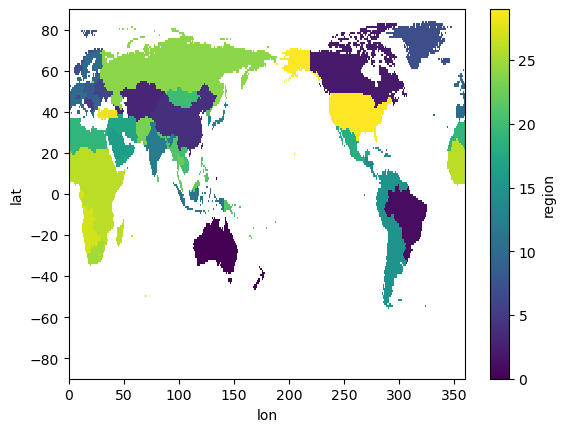

In [4]:
regionmask.plot_3D_mask(regions_mask)

# Calculate regional means

## Load crop exposure data

In [5]:
from pathlib import Path
# Directory where we'll save crop exposure data
outdir = Path("/work10/archive/CMIP6/CMIP-SSPs/outputs/crop_exposure")

Loaded ssp126 data from /work10/archive/CMIP6/CMIP-SSPs/outputs/crop_exposure/ssp126_all_models_crop_exposure_anom.nc
Loaded ssp245 data from /work10/archive/CMIP6/CMIP-SSPs/outputs/crop_exposure/ssp245_all_models_crop_exposure_anom.nc
Loaded ssp370 data from /work10/archive/CMIP6/CMIP-SSPs/outputs/crop_exposure/ssp370_all_models_crop_exposure_anom.nc
Loaded ssp585 data from /work10/archive/CMIP6/CMIP-SSPs/outputs/crop_exposure/ssp585_all_models_crop_exposure_anom.nc


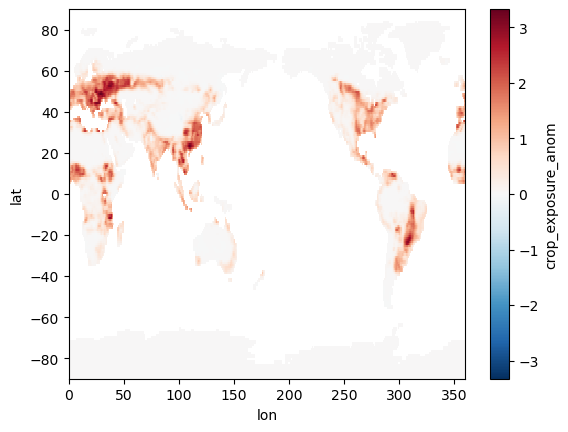

In [6]:
SSPS = ["ssp126", "ssp245", "ssp370", "ssp585"]
# Example: crop exposure under SSP5-8.5
crop_exposures = {}
for exp in SSPS:
    # Open file (run previous cell if file does not exist)
    inpath = outdir / f"{exp}_all_models_crop_exposure_anom.nc"
    ds_in = xr.open_dataset(inpath)
    # Add to dict
    crop_exposures[exp] = ds_in['crop_exposure_anom']
    print(f"Loaded {exp} data from {inpath}")

# Take mean across models
mmes = {}
for exp, crop_exposure in crop_exposures.items():
    mmes[exp] = crop_exposures[exp].mean(dim='model', skipna=False)

mmes['ssp126'].plot()

## Regional mean exposure

In [7]:
import pandas as pd

dfs = []
for ssp in SSPS:
    crops = mmes[ssp]
    # Calculate regional area-weighted mean
    weights = np.cos(np.deg2rad(crops.lat))
    crops_regional = crops.weighted(regions_mask * weights).mean(dim=("lat", "lon"))

    # Save data in DataFrame
    df = crops_regional.to_dataframe()
    df = df.rename(columns={'crop_exposure_anom': f'{ssp}_anom'})
    dfs.append(df)

# Dataframe with data from all SSPs
regional_anoms = pd.concat(dfs, axis=1)
regional_anoms = regional_anoms.T.drop_duplicates().T # Drop duplicate columns
regional_anoms

,abbrevs,names,ssp126_anom,ssp245_anom,ssp370_anom,ssp585_anom
region,,,,,,
0,ANU,ANUZ,0.104854,0.200785,0.306847,0.300511
1,BRA,BRA,0.571557,1.02598,0.898209,1.641014
2,CAN,CAN,0.145984,0.340886,0.508612,0.49146
3,CAS,CAS,0.222424,0.360758,0.476361,0.713078
4,CHN,CHN,0.543035,0.691364,0.238229,1.181112
5,EEU,EEU,1.720068,2.016571,1.5836,3.04108
6,EEUFSU,EEU-FSU,2.157184,3.696952,3.69914,4.908588
7,EFT,EFTA,0.028279,0.033869,0.038491,0.043187
8,EU1H,EU12-H,1.508536,1.627725,1.645233,3.134422


# Plot

In [8]:
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D

# Light -> dark reds, small -> large dots
SSP_STYLE = {
    "ssp126": dict(color="#e6a0a0", size=90,  label="SSP1-2.6"),
    "ssp245": dict(color="#d97a7a", size=140,  label="SSP2-4.5"),
    "ssp370": dict(color="#b83a3a", size=220, label="SSP3-7.0"),
    "ssp585": dict(color="#8b0f14", size=320, label="SSP5-8.5"),
}
 
# World-Bank-style income groups, taken from Wu et al. 2025 (https://doi.org/10.1038/s41467-025-58544-5)
# Order inside each group = order of appearance on the x-axis.
INCOME_GROUPS = {
    "High-income": ["ANUZ", "CAN", "EFTA", "EU12-H", "EU12-M", "EU15",
                    "JPKR", "MEA-H", "USA"],
    "Upper middle-income": ["BRA", "CHN", "EEU-FSU", "EEU", "IDN", "LAM-M", "MEX",
                            "OAS-M", "RUS", "SAF", "SSA-M", "TUR"],
    "Lower middle-income": ["CAS", "IND", "LAM-L", "NAF", "OAS-CPA", "OAS-L"],
    "Low-income": ["MEA-M", "PAK", "SSA-L"],
}
 
 
def draw_group_bracket(ax, x0, x1, label, y_axes=-0.25, h=0.03):
    """Bracket below the axis spanning x0..x1 (data coords), with a text label."""
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    xm = (x0 + x1) / 2
    ax.plot([x0, x0, x1, x1], [y_axes + h, y_axes, y_axes, y_axes + h],
            color="k", lw=1, transform=trans, clip_on=False)
    ax.plot([xm, xm], [y_axes, y_axes - h], color="k", lw=1,
            transform=trans, clip_on=False)
    ax.text(xm, y_axes - h - 0.03, label, transform=trans,
            ha="center", va="top", fontsize="medium")
 
 
def plot_regional_anoms(df, label_col="names", ssps=SSPS, groups=INCOME_GROUPS,
                        ylabel="Crop exposure anomaly", figsize=(17, 7), dpi=300):
    # Long format: one row per region x SSP
    cols = [f"{s}_anom" for s in ssps]
    d = df.set_index(label_col)[cols]
    d.columns = ssps
 
    # Build x positions grouped by income class (+ a small gap between groups)
    xpos, gap_edges, bracket_spans = {}, [], []
    x = 0
    for gname, regions in groups.items():
        regions = [r for r in regions if r in d.index]
        if not regions:
            continue
        start = x
        for r in regions:
            xpos[r] = x
            x += 1
        bracket_spans.append((gname, start, x - 1))
        gap_edges.append(x - 0.5)
        x += 0.6  # gap
    gap_edges = gap_edges[:-1]
 
    missing = set(d.index) - set(xpos)
    if missing:
        print(f"Warning: not in any income group, not plotted: {sorted(missing)}")
 
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.axhline(0, color="gray", ls="--", lw=1.5, zorder=0)
 
    # Dashed vertical line from min to max SSP for each region
    for r, xp in xpos.items():
        vals = d.loc[r]
        ax.vlines(xp, vals.min(), vals.max(), color="#b83a3a", ls="--", lw=1, zorder=1)
 
    # Dots: draw big ones first so small ones stay visible on top
    for s in reversed(ssps):
        st = SSP_STYLE[s]
        xs = [xpos[r] for r in xpos]
        ys = [d.loc[r, s] for r in xpos]
        ax.scatter(xs, ys, s=st["size"], color=st["color"], zorder=2,
                   edgecolor="none", label=st["label"])
 
    # Vertical separators between income groups
    for g in gap_edges:
        ax.axvline(g + 0.3, color="lightgray", lw=1, zorder=0)
 
    ax.set_xticks(list(xpos.values()))
    ax.set_xticklabels(list(xpos.keys()), rotation=90)
    ax.set_xlim(-0.7, max(xpos.values()) + 0.7)
    ax.set_ylabel(ylabel)
 
    for gname, x0, x1 in bracket_spans:
        pad = 0.5
        draw_group_bracket(ax, x0-pad, x1+pad, gname)
 
    # Legend (order low -> high forcing)
    handles = [Line2D([], [], marker="o", ls="", color=SSP_STYLE[s]["color"],
                      markersize=np.sqrt(SSP_STYLE[s]["size"]), label=SSP_STYLE[s]["label"])
               for s in ssps]
    ax.legend(handles=handles, frameon=False, loc="upper left")
 
    fig.tight_layout()
    return fig, ax


  ✓ png/Figure4_bottom.png
  ✓ pdf/Figure4_bottom.pdf


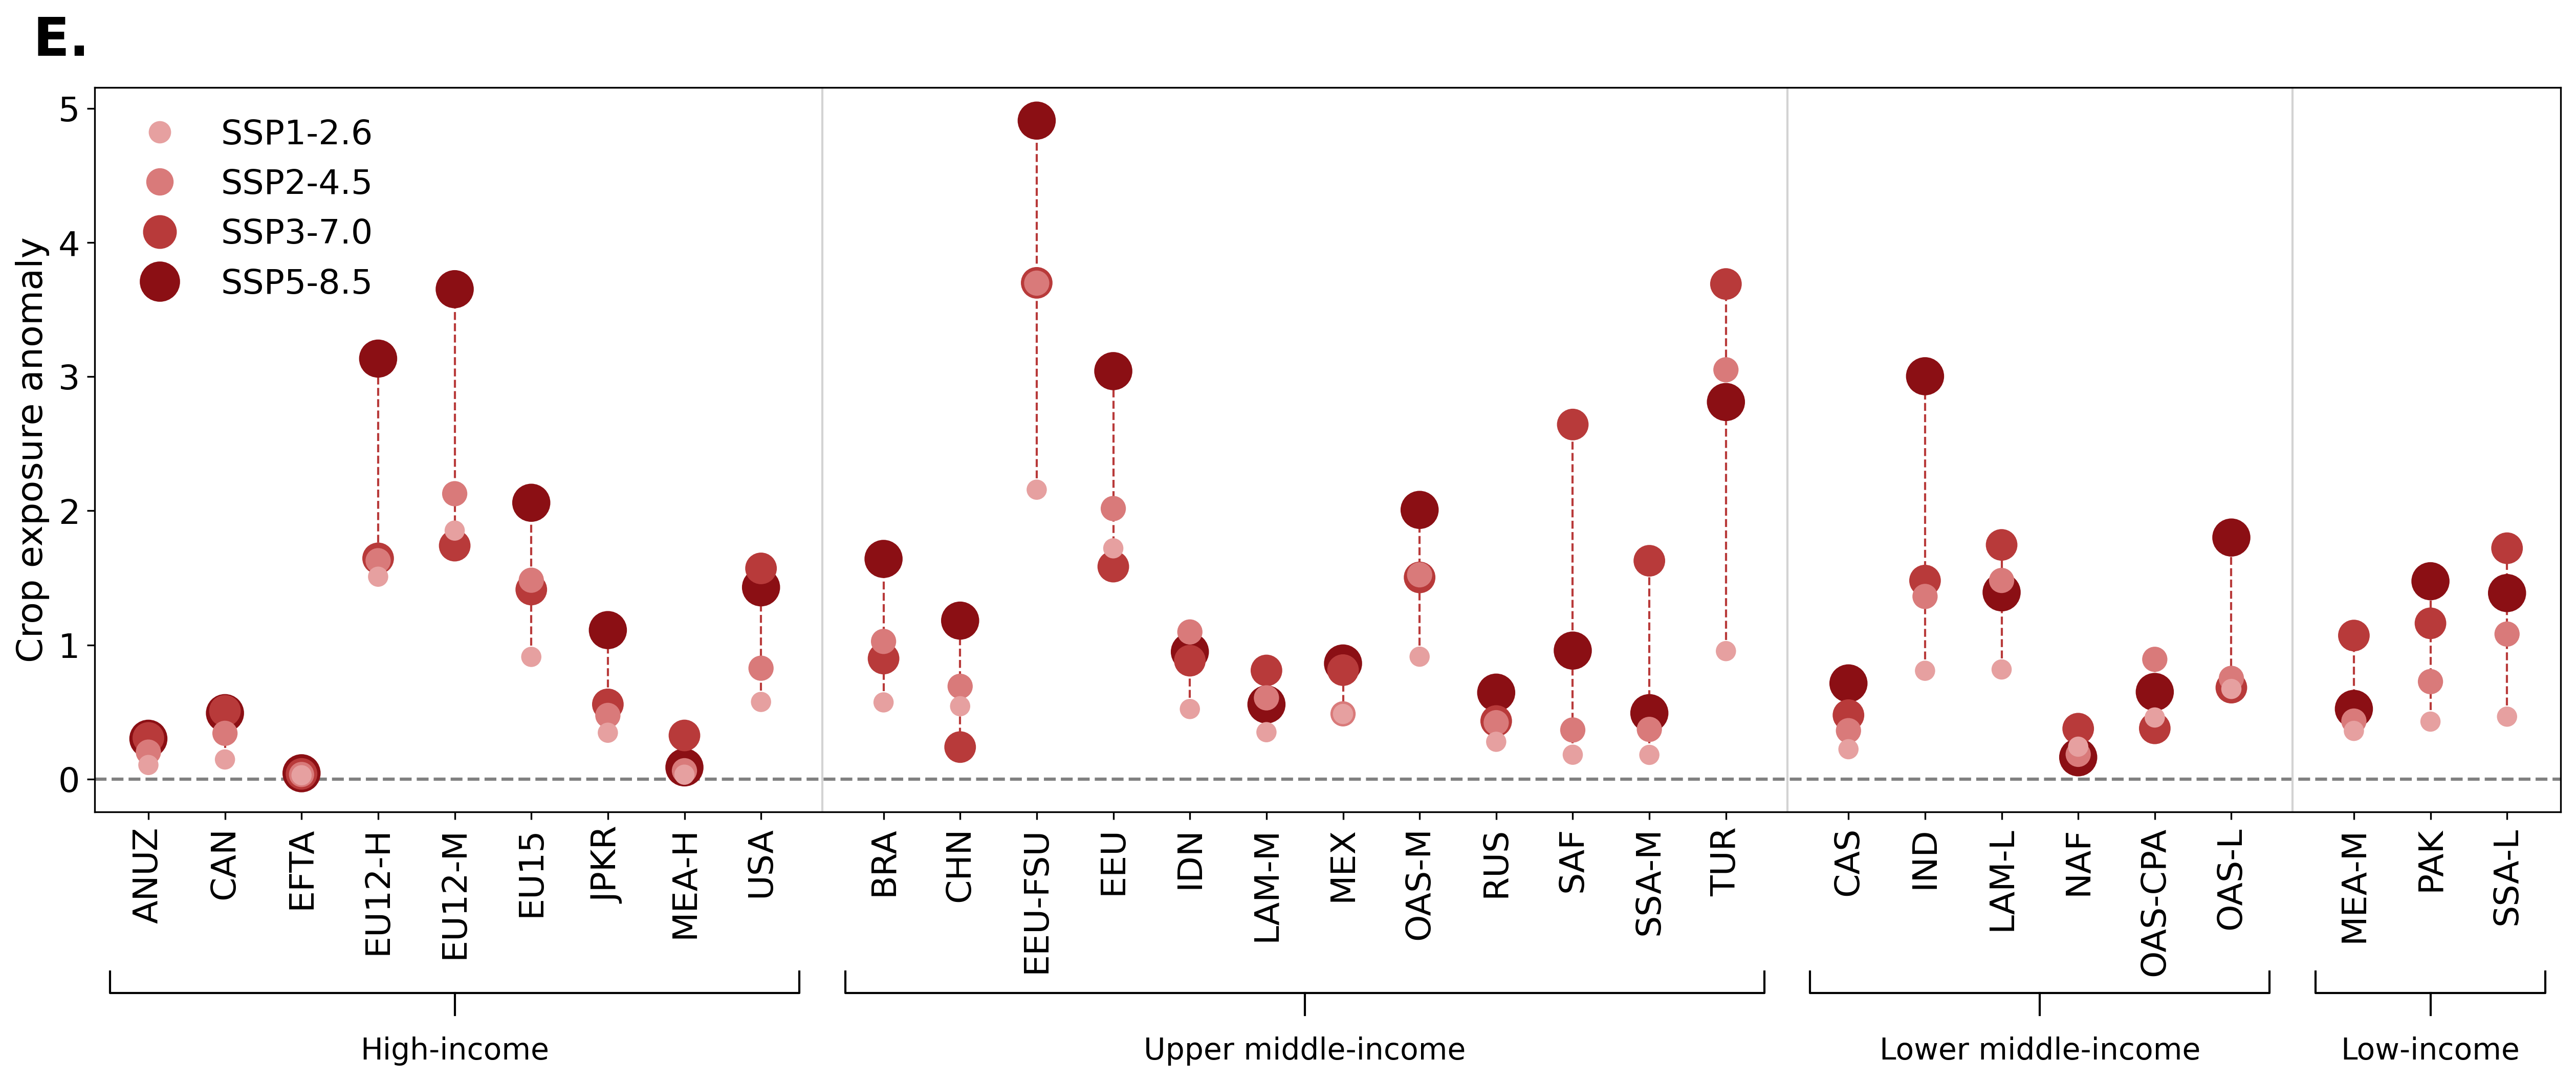

In [16]:
# Style adjustments
plot_params = {
    "figure.dpi": 300,
    "font.size": 14,
    "axes.labelsize": "large",
    "axes.titlesize": 20,        # matches ax.set_title(..., fontsize=20) in end_of_century_maps_anom.py
    "figure.titlesize": "large",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "legend.fontsize": 16,
}
plt.rcParams.update(plot_params)
fig, ax = plot_regional_anoms(regional_anoms, label_col="names",
                              ylabel="Crop exposure anomaly")

# Add label E. to panel
label = "E."
ax.text(
    -0.025, 1.10, label,
    transform=ax.transAxes,
    fontsize=25,
    fontweight='bold',
    va='top',
    ha='left'
)

# Save in current directory as png and pdf
for ext in ["png", "pdf"]:
        filename = f"{ext}/Figure4_bottom.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")